### CRETAE CHEMPROP MODELS

Run in conda env: chemprop

In [ ]:
# Build uncertainty calibrator for the EGFR small model.
!python createCalibrator.py ./01_chemprop/chemprop_model_mve_egfr_small

In [ ]:
# Build uncertainty calibrator for the EGFR full model.
!python createCalibrator.py ./chemprop_model_mve_egfr_full

In [ ]:
# Build uncertainty calibrator for the EGFR supersmall model.
!python createCalibrator.py ./chemprop_model_mve_egfr_supersmall

In [ ]:
# Build uncertainty calibrator for the EGFR supersmall model.
!python createCalibrator.py ./chemprop_model_mve_egfr_supersmall

Separate one of the 10 models to a unique folder and run the calibrator on that unique model independently

In [ ]:
!mkdir .chemprop_model_mve_egfr_fullUn8
!mkdir .chemprop_model_mve_egfr_supersmallUn8
!cp -r .chemprop_model_mve_egfr_full/model_8 .chemprop_model_mve_egfr_fullUn8/
!cp -r .chemprop_model_mve_egfr_supersmall/model_8 .chemprop_model_mve_egfr_supersmallUn8/

!python createCalibrator.py ./chemprop_model_mve_egfr_fullUn8
!python createCalibrator.py ./chemprop_model_mve_egfr_supersmallUn8

In [ ]:
# Import standard and project-specific dependencies used for prediction and uncertainty estimation.
import sys
import os
from glob import glob

import pandas as pd
import pickle
import math
import json
import torch
from lightning import pytorch as pl

from chemprop import data, featurizers
from chemprop.models import load_model
from chemprop.uncertainty import MVEEstimator

from rdkit import Chem

# Define model and test-set sources for the supersmall EGFR experiment.
model_path = "./chemprop_model_mve_egfr_supersmall"
smiles =pd.read_csv("../00_data/egfr/cleaned_egfr_supersmall.csv")
smiles = smiles[smiles["split"] == "test"]["canonical_smiles"].tolist()

# Locate the fitted calibrator corresponding to this trained model directory.
cal_path = glob(os.path.join(model_path, "*calibrator.pkl"))[0]


# Keep only valid SMILES so featurization and inference do not fail.
valid_mask = [Chem.MolFromSmiles(smi) is not None for smi in smiles]
valid_smiles = [smi for smi, is_valid in zip(smiles, valid_mask) if is_valid]

# Load one or more checkpoints from a directory, or a single model file path.
if os.path.isdir(model_path):
    checkpoint_files = glob(os.path.join(model_path, "model_*/checkpoints/best*.ckpt")) + glob(os.path.join(model_path, "*.pt"))
    if checkpoint_files:
        models = [load_model(ckpt, multicomponent=False) for ckpt in checkpoint_files]

else:
    print(f"Loading single model: {model_path}")
    models = [load_model(model_path, multicomponent=False)]

# Freeze model parameters and set eval mode for deterministic inference.
for model in models:
    model.eval()
    for param in model.parameters():
        param.requires_grad = False

# Build Chemprop molecular graph features for each valid molecule.
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()


test_data = [data.MoleculeDatapoint.from_smi(smi) for smi in valid_smiles]
test_dset = data.MoleculeDataset(test_data, featurizer=featurizer)
test_loader = data.build_dataloader(test_dset, num_workers=0, shuffle=False)

# Set up uncertainty estimator and lightweight trainer backend.
unc_estimator = MVEEstimator()
trainer = pl.Trainer(
    logger=False,
    enable_progress_bar=False,
    accelerator="cuda" if torch.cuda.is_available() else "cpu",
    devices=1
)

# Load calibrator object to transform raw predictive uncertainty.
with open(cal_path, "rb") as f:
    calibrator = pickle.load(f)

# Run prediction only when there are valid molecules in the test list.
if len(valid_smiles)>0:
    predictions, uncertainties = unc_estimator(test_loader, models, trainer)

    # Average across models if multiple
    if len(models) > 1:
        predictions = predictions.mean(0)
        uncertainties = uncertainties.mean(0)
    else:
        predictions = predictions[0]
        uncertainties = uncertainties[0]

    # Convert tensors to numpy and compute calibrated uncertainty values.
    calibrated_uncertainties = calibrator.apply(uncertainties.detach().clone())
    scores = predictions.squeeze().numpy()
    raw_uncertainties = uncertainties.squeeze().numpy()
    caluncertainties = calibrated_uncertainties.squeeze().numpy()

else:
    # Keep empty outputs when no valid inputs are available.
    scores=[]
    raw_uncertainties=[]
    caluncertainties=[]


In [ ]:
# Save supersmall-model predictions and uncertainties to disk.
predictedSmall=pd.DataFrame({
    "canonical_smiles": valid_smiles,
    "predicted_pChEMBL Value": scores,
    "raw_uncertainty": raw_uncertainties,
    "calibrated_uncertainty": caluncertainties
})
predictedSmall.to_csv("./predictionsSmall.csv", index=False)

In [ ]:
# Import dependencies for full-model inference and uncertainty calibration.
import sys
import os
from glob import glob

import pandas as pd
import pickle
import math
import json
import torch
from lightning import pytorch as pl

from chemprop import data, featurizers
from chemprop.models import load_model
from chemprop.uncertainty import MVEEstimator

from rdkit import Chem

# Define model and test-set paths for the full EGFR model.
model_path = "./chemprop_model_mve_egfr_full"
smiles =pd.read_csv("../00_data/egfr/cleaned_egfr.csv")
smiles = smiles[smiles["split"] == "test"]["canonical_smiles"].tolist()

# Locate the precomputed calibrator file for this model folder.
cal_path = glob(os.path.join(model_path, "*calibrator.pkl"))[0]


# Filter out invalid SMILES before graph featurization.
valid_mask = [Chem.MolFromSmiles(smi) is not None for smi in smiles]
valid_smiles = [smi for smi, is_valid in zip(smiles, valid_mask) if is_valid]

# Load all ensemble checkpoints from directory or one model file.
if os.path.isdir(model_path):
    checkpoint_files = glob(os.path.join(model_path, "model_*/checkpoints/best*.ckpt")) + glob(os.path.join(model_path, "*.pt"))
    if checkpoint_files:
        models = [load_model(ckpt, multicomponent=False) for ckpt in checkpoint_files]

else:
    print(f"Loading single model: {model_path}")
    models = [load_model(model_path, multicomponent=False)]

# Put models in eval mode and disable gradients for inference speed.
for model in models:
    model.eval()
    for param in model.parameters():
        param.requires_grad = False

# Create Chemprop dataset/dataloader from valid SMILES.
featurizer = featurizers.SimpleMoleculeMolGraphFeaturizer()


test_data = [data.MoleculeDatapoint.from_smi(smi) for smi in valid_smiles]
test_dset = data.MoleculeDataset(test_data, featurizer=featurizer)
test_loader = data.build_dataloader(test_dset, num_workers=0, shuffle=False)

# Instantiate uncertainty estimator and Lightning trainer.
unc_estimator = MVEEstimator()
trainer = pl.Trainer(
    logger=False,
    enable_progress_bar=False,
    accelerator="cuda" if torch.cuda.is_available() else "cpu",
    devices=1
)

# Load uncertainty calibrator used to post-process raw uncertainty.
with open(cal_path, "rb") as f:
    calibrator = pickle.load(f)

# Execute inference and calibration if there are valid molecules.
if len(valid_smiles)>0:
    predictions, uncertainties = unc_estimator(test_loader, models, trainer)

    # Average across models if multiple
    if len(models) > 1:
        predictions = predictions.mean(0)
        uncertainties = uncertainties.mean(0)
    else:
        predictions = predictions[0]
        uncertainties = uncertainties[0]

    # Materialize prediction and uncertainty arrays for downstream analysis.
    calibrated_uncertainties = calibrator.apply(uncertainties.detach().clone())
    scores = predictions.squeeze().numpy()
    raw_uncertainties = uncertainties.squeeze().numpy()
    caluncertainties = calibrated_uncertainties.squeeze().numpy()

else:
    # Provide empty outputs if no valid test molecules are found.
    scores=[]
    raw_uncertainties=[]
    caluncertainties=[]


In [ ]:
# Save full-model predictions and uncertainties to disk.
predictedFull=pd.DataFrame({
    "canonical_smiles": valid_smiles,
    "predicted_pChEMBL Value": scores,
    "raw_uncertainty": raw_uncertainties,
    "calibrated_uncertainty": caluncertainties
})
predictedFull.to_csv("./predictionsFull.csv", index=False)

In [ ]:
# Load both prediction files for side-by-side comparison.
import pandas as pd
predictedSmall=pd.read_csv("./predictionsSmall.csv")
predictedFull=pd.read_csv("./predictionsFull.csv")

False Positives: 141
False Negatives: 828
True Positives: 3479
True Negatives: 80


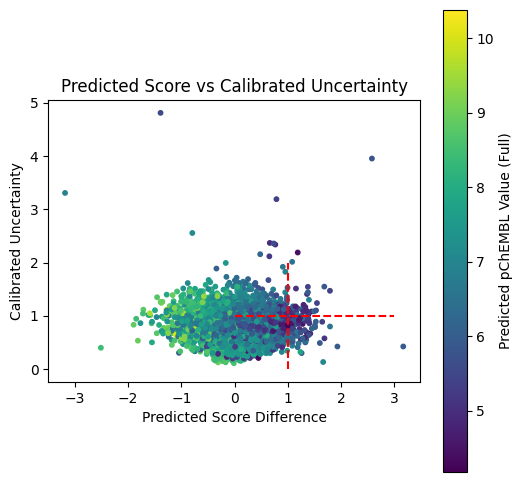

Correlation between log-transformed predicted score difference and log-calibrated uncertainty: 0.2445


In [ ]:
# Compare prediction disagreement versus calibrated uncertainty.
import matplotlib.pyplot as plt
import numpy as np

# Calculate classification-like counts based on score-difference and uncertainty thresholds.
diff = abs(predictedSmall["predicted_pChEMBL Value"] - predictedFull["predicted_pChEMBL Value"])
unc = predictedSmall["calibrated_uncertainty"]

true_positives = ((diff <= 1) & (unc <= 1)).sum()
true_negatives = ((diff > 1) & (unc >1)).sum()
false_positives = ((diff >= 1) & (unc <= 1)).sum()
false_negatives = ((diff < 1) & (unc > 1)).sum()

print(f"False Positives: {false_positives}")
print(f"False Negatives: {false_negatives}")
print(f"True Positives: {true_positives}")
print(f"True Negatives: {true_negatives}")

# Scatter plot of prediction delta against calibrated uncertainty.
plt.figure(figsize=(6,6))
sc = plt.scatter(
    predictedSmall["predicted_pChEMBL Value"] - predictedFull["predicted_pChEMBL Value"],
    predictedSmall["calibrated_uncertainty"],
    s=10,
    alpha=1,
    cmap="viridis",
    c=predictedFull["predicted_pChEMBL Value"]
)
plt.xlabel("Predicted Score Difference")
plt.ylabel("Calibrated Uncertainty")
plt.plot([0.01, 3], [1, 1], 'r--')  # Reference line for perfect correlation
plt.plot([1,1], [0, 2], 'r--')  # Reference line for perfect correlation
plt.title("Predicted Score vs Calibrated Uncertainty")
plt.gca().set_aspect('equal', adjustable='box')
cbar = plt.colorbar(sc)
cbar.set_label("Predicted pChEMBL Value (Full)")
plt.show()

# Compute log-space correlation to reduce the effect of outliers.
log_diff = np.log1p(abs(predictedSmall["predicted_pChEMBL Value"] - predictedFull["predicted_pChEMBL Value"]))
log_uncertainty = np.log1p(predictedSmall["calibrated_uncertainty"])
correlation_log = log_diff.corr(log_uncertainty)
print(f"Correlation between log-transformed predicted score difference and log-calibrated uncertainty: {correlation_log:.4f}")


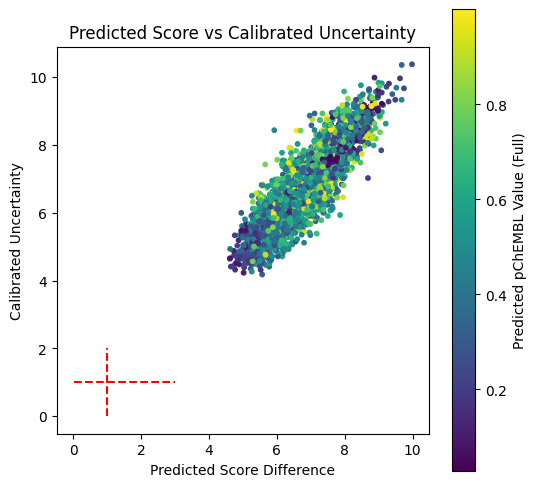

In [ ]:
# Restrict to low-uncertainty full-model samples.
mask = ((predictedFull["calibrated_uncertainty"] <= 1))


plt.figure(figsize=(6,6))
sc = plt.scatter(
    predictedSmall["predicted_pChEMBL Value"][mask],
    predictedFull["predicted_pChEMBL Value"][mask],
    s=10,
    alpha=1,
    cmap="viridis",
    c=predictedFull["calibrated_uncertainty"][mask]
)
plt.xlabel("Predicted Score Difference")
plt.ylabel("Calibrated Uncertainty")
plt.plot([0.01, 3], [1, 1], 'r--')  # Reference line for perfect correlation
plt.plot([1,1], [0, 2], 'r--')  # Reference line for perfect correlation
plt.title("Predicted Score vs Calibrated Uncertainty")
plt.gca().set_aspect('equal', adjustable='box')
cbar = plt.colorbar(sc)
cbar.set_label("Predicted pChEMBL Value (Full)")
plt.show()

False Positives: 1
False Negatives: 296
True Positives: 629
True Negatives: 2


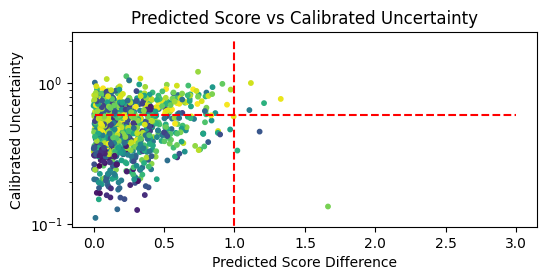

Correlation between log-transformed predicted score difference and log-calibrated uncertainty: 0.2445


In [ ]:
# Repeat the comparison under a stricter uncertainty filter.
import matplotlib.pyplot as plt
import numpy as np

# Calculate false positives and false negatives
diff = predictedSmall["predicted_pChEMBL Value"] - predictedFull["predicted_pChEMBL Value"]
unc = predictedSmall["calibrated_uncertainty"]


# Apply mask for low-uncertainty full-model samples only.
mask = ((predictedFull["calibrated_uncertainty"] <= 0.25))
diff = (predictedSmall["predicted_pChEMBL Value"] - predictedFull["predicted_pChEMBL Value"])[mask]
unc = predictedSmall["calibrated_uncertainty"][mask]

# Compute confusion-style counts at the stricter threshold setting.
true_positives = ((diff <= 1) & (unc <= 0.6)).sum()
true_negatives = ((diff > 1) & (unc > 0.6)).sum()
false_positives = ((diff >= 1) & (unc <= 0.6)).sum()
false_negatives = ((diff < 1) & (unc > 0.6)).sum()

print(f"False Positives: {false_positives}")
print(f"False Negatives: {false_negatives}")
print(f"True Positives: {true_positives}")
print(f"True Negatives: {true_negatives}")


# Visualize absolute prediction difference vs calibrated uncertainty.
plt.figure(figsize=(6,6))
plt.scatter(abs(predictedSmall["predicted_pChEMBL Value"]-predictedFull["predicted_pChEMBL Value"])[mask], predictedSmall["calibrated_uncertainty"][mask], s=10, alpha=1, cmap="viridis", c=predictedFull["calibrated_uncertainty"][mask])
plt.yscale("log")
#plt.ylim(0,4)
#plt.xlim(0,4)

plt.xlabel("Predicted Score Difference")
plt.ylabel("Calibrated Uncertainty")
plt.plot([0.01, 3], [0.6, 0.6], 'r--')  # Reference line for perfect correlation
plt.plot([1,1], [0, 2], 'r--')  # Reference line for perfect correlation
plt.title("Predicted Score vs Calibrated Uncertainty")
plt.gca().set_aspect('equal', adjustable='box')
plt.show()

# Report log-space correlation for the unmasked global vectors.
log_diff = np.log1p(abs(predictedSmall["predicted_pChEMBL Value"] - predictedFull["predicted_pChEMBL Value"]))
log_uncertainty = np.log1p(predictedSmall["calibrated_uncertainty"])
correlation_log = log_diff.corr(log_uncertainty)
print(f"Correlation between log-transformed predicted score difference and log-calibrated uncertainty: {correlation_log:.4f}")
